In [ ]:
# Mount Google Drive to access your data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pyshtools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.9/13.9 MB 85.6 MB/s eta 0:00:00


[CFG] device=cuda  dtype=float64
[CFG] window=4.0h  embed_dim=48
[CFG] ABLATION = 'no_gravity'  -> gravity=False frame=RTN ode=True anchor=True
[CFG] U_TARGET_DIM=1.20e+01  fourier_scale_force=20.0  bin_step=16873s
[CFG] gravity backend requested: pyshtools (degree 60)
Loading 14 file(s)...
  GNV1B_2025-11-01_C_04.txt  (86400 rows)
  GNV1B_2025-11-02_C_04.txt  (86400 rows)
  GNV1B_2025-11-03_C_04.txt  (86400 rows)
  GNV1B_2025-11-04_C_04.txt  (86400 rows)
  GNV1B_2025-11-05_C_04.txt  (86400 rows)
  GNV1B_2025-11-06_C_04.txt  (86400 rows)
  GNV1B_2025-11-07_C_04.txt  (86400 rows)
  GNV1B_2025-11-08_C_04.txt  (86400 rows)
  GNV1B_2025-11-09_C_04.txt  (86400 rows)
  GNV1B_2025-11-10_C_04.txt  (86400 rows)
  GNV1B_2025-11-11_C_04.txt  (86400 rows)
  GNV1B_2025-11-12_C_04.txt  (86400 rows)
  GNV1B_2025-11-13_C_04.txt  (86400 rows)
  GNV1B_2025-11-14_C_04.txt  (86400 rows)
  1209600 samples | arc 14.00 days | |r0|=6835624.8 m  |v0|=7638.1 m/s
  Loading cached ECI transform: /content/drive/My

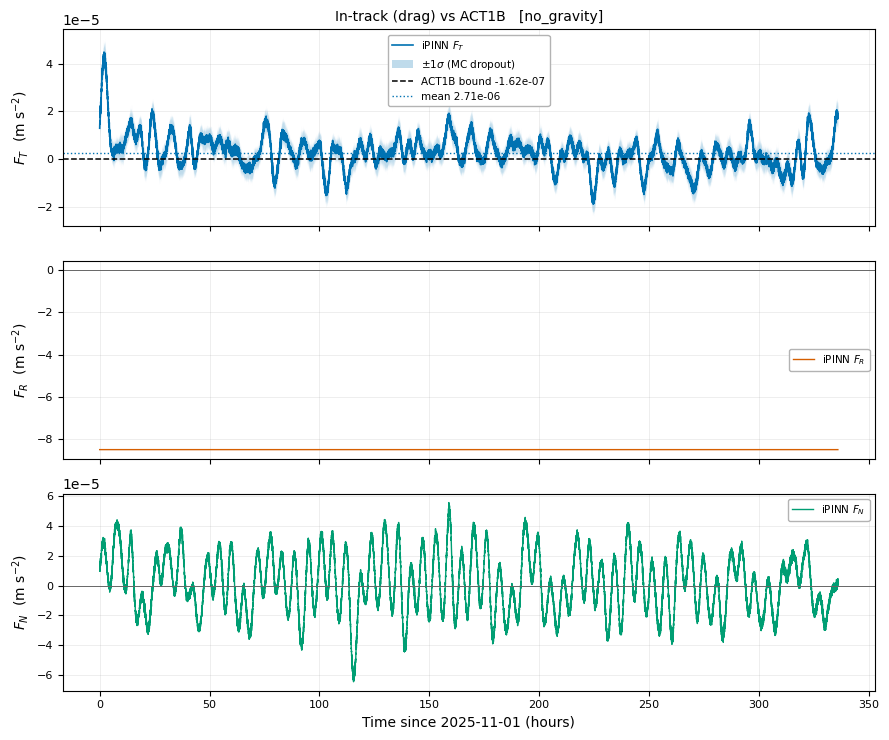

In [ ]:
"""
GRACE-FO GPS -> nongravitational acceleration : INVERSE PINN

KNOWN LIMITATION (documented)

The torch gravity field in the physics residual (gravity_j2_to_j5_torch)
evaluates J2-J5 directly on ECI positions, with no differentiable
Earth-fixed rotation. This leaves a ~0.14 deg pole misalignment vs the
true figure axis. For a zonal-only field the resulting error is small and
mostly periodic (~1e-9 to 1e-8 m/s^2), not a secular bias, so it barely
shifts the mean Ft -- but it is a real residual error source. A proper fix
would embed a differentiable GCRS<->ITRS rotation in the autograd graph;
that is left for future work, and matters only if the recovered time
series shows structure tied to orbital longitude.

Author: reformulation for paul.reva | Colab-ready, float64 throughout.
"""

import os
import math
import time
from glob import glob

import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import matplotlib.pyplot as plt

from astropy.utils import iers
iers.conf.auto_download = False
iers.conf.auto_max_age = None
from astropy.time import Time
from astropy.coordinates import (
    ITRS, GCRS, CartesianDifferential, CartesianRepresentation,
    get_body, solar_system_ephemeris)
import astropy.units as u

# 'builtin' is a low-precision analytic ephemeris that comes with astropy
# no network access needed (unlike 'jpl', which would hit the same kind of
# hang the IERS auto-download caused). Plenty accurate for a ~1e-6 m/s^2
# third-body term against a ~1e-7 target.
solar_system_ephemeris.set('builtin')



# CONFIG

class CFG:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    DTYPE  = torch.float64

    # data
    DATA_FOLDER_PATH = "/content/drive/MyDrive/science_fair/GRACEFO_Nov2025"
    FILE_PATTERN     = "GNV1B_2025-11-*_C_04.txt"
    SKIP_ROWS_COUNT  = 148
    COLUMNS_TO_USE   = [0, 3, 4, 5, 9, 10, 11]
    CACHE_ECI        = True   # cache the astropy frame transform to .npy

    # physical constants / gravity
    R_EARTH  = 6378137.0
    MU_EARTH = 3.986004418e14
    J2 =  1.08262668e-3
    J3 = -2.53265649e-6
    J4 = -1.61962159e-6
    J5 = -2.27296083e-7

    # Third-body point masses (Sun, Moon). Without these, the former version's anchor
    # measured Fr~2.1e-6, Fn~-1.1e-6 m/s^2 -- unmodeled lunisolar gravity,
    # 4-15x LARGER than the old U_TARGET_DIM=5e-7 bound. That saturated
    # ForceNet's tanh output during Stage 2 warmup
    # and left Stage 3 with a physics-residual floor no amount of training
    # could close, since gravity error isn't something F is allowed, or
    # able, once bounded correctly, to absorb. See module notes.
    GM_SUN  = 1.32712440018e20     # m^3/s^2
    GM_MOON = 4.9048695e12         # m^3/s^2
    EPHEM_STEP_SEC = 300.0         # Sun/Moon move slowly; coarse grid is fine

    # nondimensionalization ( do not change without
    # rescaling U_TARGET_ND)
    L0 = 6835624.8
    T0 = math.sqrt(L0**3 / MU_EARTH)
    V0 = L0 / T0

    # The measured radial anchor mean is ~2.1e-6 m/s^2 and is NOT lunisolar
    # (adding third-body left it unchanged). It's higher-degree static
    # gravity leaking into radial. ForceNet must be able to represent it
    # without tanh-saturating, so the bound sits comfortably above it.
    # (This does not affect the in-track drag target of ~1.4e-7, since there's
    # ~20x headroom there.)
    U_TARGET_DIM = 3.0e-6          # m/s^2, ForceNet output bound
    U_TARGET_ND  = None            # set after class def
    GM_SUN_ND    = None
    GM_MOON_ND   = None

    # ACT1B along-track (lin_accl_x) reference, arc mean 2025-11-01..14.
    # Maneuver-screened (Nov 12-13 excluded: positive daily mean is impossible
    # for a dissipative force -> thruster events) and bias-corrected using the
    # drag<=0 constraint. See act1b_reference.py.
    # NB: ACT1B is NOT bias-calibrated, and the bias correction is a LOWER
    # bound, so this is an order-of-magnitude reference, not ground truth.
    # Used only for reporting/plots -- it never enters any loss.
    # (Previous value -1.4073e-07 was a Nov-1-only mean.)
    ACT1B_FT_REFERENCE = -2.2183e-7   # m/s^2

    #  windowed trajectory net
    # The ONLY thing distinguishing windows is the per-window embedding (the
    # Fourier input is local time, identical across windows), so it must
    # encode absolute orbital state for each of ~84 windows. 16 dims was too
    # few -- Stage 1 plateaued at ~1e-5 (~25 km). Bigger embedding + a bit
    # more capacity lets the fit reach the level where the ODE-coupling term
    # is physically meaningful, not just the binned anchor carrying the result.
    WINDOW_HOURS   = 4.0            # ~2.5 orbital revolutions per window
    EMBED_DIM      = 48
    hidden_traj    = 128
    depth_traj     = 5
    n_fourier_traj = 64
    fourier_scale_traj = 4.0        # tuned for ~2-3 cycles across [-1,1]

    # ForceNet
    hidden_force    = 128
    depth_force     = 5
    n_fourier_force = 128
    # Applied to a time input NORMALIZED to [-1,1] over the whole arc (see
    # ForceNet.t_scale). Raw nondim time (0..~1352) would make scale*time
    # produce enormous phases and alias the features into noise.
    #
    # Raised 6 -> 20. At 6 (~2.3-day resolution) ForceNet fit only the MEAN
    # and discarded the variation present in its own target: the 3-orbit
    # binned anchor has in-track std 1.15e-07 (~7.4e-08 real signal above an
    # 8.8e-08 noise floor), yet ForceNet's output varied by just 5.0e-09.
    # Day-to-day is where the real drag signal lives -- maneuver-screened
    # ACT1B daily means swing -1.29e-07 .. -1.33e-08 across the arc.
    # 20 cycles / 14 days => ~17-hour features, comfortably inside what the
    # 4.7-hour anchor bins can support (Nyquist allows up to ~36).
    # Tradeoff: more capacity also means more ability to fit per-bin noise;
    # MC dropout + f_smooth_wt are the guards. If the recovered series looks
    # like it is chasing bin-to-bin scatter, lower this or raise f_smooth_wt.
    fourier_scale_force = 20.0
    dropout_p  = 0.05
    mc_samples = 30

    # Anchor reconstruction
    # 'velocity_savgol'  : a_kin = d(v)/dt by SG on the RAW measured velocity,
    #                      then subtract modeled gravity. Simple, but it
    #                      differentiates a signal carrying the full ~7.6 km/s
    #                      orbital velocity, so SG's ~1e-6 relative gain error
    #                      at orbital frequency multiplies the ~8.5 m/s^2
    #                      gravity term into a ~1e-5 m/s^2 ECI error. Projected
    #                      onto the CO-ROTATING R_hat/T_hat that error
    #                      rectifies into a DC bias, while N_hat (nearly
    #                      inertially fixed) stays clean -- exactly the
    #                      observed pattern (Fr ~ 1.8e-6, Fn ~ 1.7e-9).
    #
    # 'reduced_dynamic'  : integrate a reference orbit per short arc, then
    #                      differentiate only the VELOCITY RESIDUAL
    #                      dv = v_obs - v_ref (metres/s, not km/s). The SG
    #                      systematic scales with the amplitude of what is
    #                      differentiated, so it drops by ~4 orders of
    #                      magnitude. This is the standard reduced-dynamic /
    #                      short-arc technique from GPS-based POD.
    #

    ANCHOR_METHOD = 'reduced_dynamic'

    SG_WINDOW_SEC = 181            # used by 'velocity_savgol'
    SG_POLYORDER  = 4
    GAP_FACTOR    = 1.5

    # reduced-dynamic parameters
    RD_ARC_ORBITS   = 2.0          # arc length; longer => reference diverges more
    RD_OVERLAP_FRAC = 0.5          # overlap-add fraction (Hanning tapered)
    RD_SG_WINDOW_SEC = 601         # SG window for d(dv)/dt
    RD_SG_POLYORDER  = 4
    RD_RTOL = 1e-10                # reference-orbit integrator tolerances
    RD_ATOL = 1e-9

    # Anchor time-bin width, in WHOLE ORBITS. The ~1e-4 m/s^2 scatter in the
    # per-point in-track anchor is NOT white noise -- it's once/twice-per-rev
    # gravity-mismodeling residual, coherent within any sub-orbit window, so
    # binning at 120s did not reduce it (verified: 9.78e-5 -> 9.64e-5) and the
    # ~2e-8 nondim drag mean stayed buried 500x under it, leaving ForceNet
    # stuck at ~0. Averaging over an INTEGER number of orbital periods cancels
    # the periodic residual, collapsing per-bin scatter toward the drag scale
    # so an L2 fit can actually recover the mean. The nondim orbital period is
    # exactly 2*pi*T0, so BIN_STEP_SEC is set to an exact multiple below.
    BIN_ORBITS   = 3
    BIN_STEP_SEC = BIN_ORBITS * 2.0 * math.pi * T0   # ~3 orbits (~4.7 hr)

    # training
    N_data_sample   = 20000
    per_window_phys = 180           # collocation points per window per epoch

    # Epoch counts trimmed to observed convergence (measured on the degree-60
    # 'full' run): Stage 1 data-loss plateaus ~1e3-1.5e3 epochs and is noisy
    # after; Stage 3 Ft is flat from ~epoch 200 (ratio drifted only 2.021 ->
    # 2.031 over 3200 further epochs). Running 3000/6000 burned ~47 min per
    traj_pretrain_epochs  = 1500
    force_anchor_epochs   = 2000
    joint_epochs           = 2000

    lr = 1e-3

    # Loss weights. All physics terms are now PLAIN (un-normalized) MSE in
    # nondim acceleration units. O(1)-scaled, so their gradients w.r.t. the
    # trajectory net are O(1) and can't blow it up the way the U_TARGET-
    # normalized residual did (Bug 2). ForceNet is trained mainly by
    # fanchor (clean binned target); the ODE term couples it weakly.
    data_wt        = 5.0           # keep the orbit locked to GPS data
    kin_wt         = 1.0           # dx/dt = v   (autograd, 1st-derivative)
    phys_wt        = 1.0           # dv/dt = a_grav + F  (autograd, 2nd-derivative)
    fanchor_wt     = 1.0           # ForceNet <- clean binned nongrav anchor (L2)
    continuity_wt  = 10.0          # window-boundary state continuity
    f_smooth_wt    = 1e-3          # ForceNet temporal smoothness

    USE_ANTIVELOCITY  = False       # OFF by default, see module docstring
    antivelocity_wt   = 5.0
    dissipation_wt    = 20.0

    log_every = 200



# GRAVITY BACKEND
#   'analytic'  : J2-J5 zonal + third body (fast, self-contained, trusted --
#                 this is what produced the -1.75e-7 in-track baseline).
#   'pyshtools' : high-degree EGM2008 static field to GRAVITY_DEGREE, via the
#                 pyshtools library (pip install pyshtools; auto-downloads the
#                 coefficient set once). This is what actually removes the
#                 higher-degree static signal now leaking into the radial
#                 channel (~2e-6 m/s^2). If pyshtools is missing or errors, or
#                 the result fails a sanity check, it FALLS BACK to analytic
#                 and says so, the run never breaks. Verify the
#                 printed "mean Fr" drops vs analytic before trusting it.

CFG.GRAVITY_BACKEND = 'pyshtools'      # 'pyshtools' or 'analytic'
CFG.GRAVITY_DEGREE  = 60               # max spherical-harmonic degree if pyshtools
CFG.GRAVITY_DECIM   = 30               # evaluate high-degree field every Nth sample, interp the rest


# ABLATION SELECTOR, for the "what physics does the work" experiments.
# Set CFG.ABLATION to one of the keys below and re-run; each isolates one
# physics mechanism. Per-mode overrides (u_target/f_scale/bin_orbits) keep
# each variant numerically runnable so the comparison is about the physics,
# not about one variant silently blowing up.
#
#   full        : all physics on                       (the model)
#   no_gravity  : don't subtract a_grav -> force must   (expect: radial swamped
#                 explain ALL acceleration              by gravity; decomposition
#                                                       physically meaningless)
#   no_rtn      : force parameterized in raw ECI, not   (expect: worse/no clean
#                 the r,v-tied RTN frame                RTN decomposition)
#   no_ode      : drop the autograd ODE-residual term   (isolates how much the
#                 (anchor + data only)                  ODE coupling contributes)
#   no_anchor   : drop the anchor supervision, force     (this is the v5 regime;
#                 driven ONLY by the ODE residual        expect: F ~ 0, it fails)

CFG.ABLATION = 'full'

# u_target / f_scale / bin_orbits of None mean "keep the CFG class-body value".
# Only spell out an override where the ablation genuinely needs a different
# number, so editing the class body can't be silently clobbered by this table
# (which is exactly what happened when fourier_scale_force was raised to 20
# in the class body and this table quietly reset it to 6).
_ABLATIONS = {
    #              gravity  frame   ode    anchor  u_target  f_scale  bin_orbits
    'full':       (True,   'RTN',  True,  True,   None,     None,    None),
    'no_gravity': (False,  'RTN',  True,  True,   12.0,     None,    None),
    # ECI force rotates once per orbit, so representing it needs ~215 cycles
    # across 14 days and sub-orbit bins. NOTE: at 120 s bins the anchor noise
    # (~1e-6) far exceeds the signal, so this ablation is limited by BOTH
    # representation and noise -- report it as such rather than as a clean
    # test of frame choice alone.
    'no_rtn':     (True,   'ECI',  True,  True,   None,     250.0,   0),
    'no_ode':     (True,   'RTN',  False, True,   None,     None,    None),
    'no_anchor':  (True,   'RTN',  True,  False,  None,     None,    None),
}
(CFG.USE_GRAVITY, CFG.FORCE_FRAME, CFG.USE_ODE, CFG.USE_ANCHOR,
 _u_target, _f_scale, _bin_orbits) = _ABLATIONS[CFG.ABLATION]
if _u_target is not None:
    CFG.U_TARGET_DIM = _u_target
if _f_scale is not None:
    CFG.fourier_scale_force = _f_scale
if _bin_orbits is None:
    _bin_orbits = CFG.BIN_ORBITS

# bin width: whole orbits for RTN (cancels periodic residual), or a short
# sub-orbit bin for ECI (where the force rotates at orbital frequency and
# must NOT be averaged away).
CFG.BIN_STEP_SEC = (_bin_orbits * 2.0 * math.pi * CFG.T0) if _bin_orbits > 0 else 120.0

# recompute derived scales now that the ablation may have changed U_TARGET_DIM
CFG.U_TARGET_ND = CFG.U_TARGET_DIM * (CFG.T0**2 / CFG.L0)
# Same nondim scheme that makes MU_EARTH_nd == 1: GM_nd = GM_dim * T0^2/L0^3
CFG.GM_SUN_ND  = CFG.GM_SUN  * (CFG.T0**2 / CFG.L0**3)
CFG.GM_MOON_ND = CFG.GM_MOON * (CFG.T0**2 / CFG.L0**3)

print(f"[CFG] device={CFG.device}  dtype=float64")
print(f"[CFG] window={CFG.WINDOW_HOURS}h  embed_dim={CFG.EMBED_DIM}")
print(f"[CFG] ABLATION = '{CFG.ABLATION}'  -> gravity={CFG.USE_GRAVITY} "
      f"frame={CFG.FORCE_FRAME} ode={CFG.USE_ODE} anchor={CFG.USE_ANCHOR}")
print(f"[CFG] U_TARGET_DIM={CFG.U_TARGET_DIM:.2e}  fourier_scale_force={CFG.fourier_scale_force}  "
      f"bin_step={CFG.BIN_STEP_SEC:.0f}s")
print(f"[CFG] gravity backend requested: {CFG.GRAVITY_BACKEND}"
      + (f" (degree {CFG.GRAVITY_DEGREE})" if CFG.GRAVITY_BACKEND == 'pyshtools' else ""))



# FRAME TRANSFORMS

def _obstimes(t_gps_sec):
    t_base = Time(t_gps_sec[0], format='gps', scale='utc')
    return t_base + (t_gps_sec - t_gps_sec[0]) * u.s


def ecef_state_to_eci(r_ecef, v_ecef, times):
    rep = CartesianRepresentation(
        r_ecef[:, 0] * u.m, r_ecef[:, 1] * u.m, r_ecef[:, 2] * u.m)
    dif = CartesianDifferential(
        v_ecef[:, 0] * u.m / u.s, v_ecef[:, 1] * u.m / u.s, v_ecef[:, 2] * u.m / u.s)
    itrs = ITRS(rep.with_differentials({'s': dif}), obstime=times)
    gcrs = itrs.transform_to(GCRS(obstime=times))
    r_eci = gcrs.cartesian.xyz.to(u.m).value.T
    v_eci = gcrs.cartesian.differentials['s'].d_xyz.to(u.m / u.s).value.T
    return r_eci, v_eci


def ecef_pos_to_eci(r_ecef, times):
    rep = CartesianRepresentation(
        r_ecef[:, 0] * u.m, r_ecef[:, 1] * u.m, r_ecef[:, 2] * u.m)
    itrs = ITRS(rep, obstime=times)
    gcrs = itrs.transform_to(GCRS(obstime=times))
    return gcrs.cartesian.xyz.to(u.m).value.T



# GRAVITY  torch (nondim, differentiable, used inside the physics residual)

def gravity_j2_to_j5_torch(pos_nd, r_mag):
    x = pos_nd[:, 0:1]; y = pos_nd[:, 1:2]; z = pos_nd[:, 2:3]
    r = r_mag
    r2 = r**2; r4 = r**4; r5 = r**5; r7 = r**7
    R_E_nd = CFG.R_EARTH / CFG.L0
    Re2, Re3, Re4, Re5 = R_E_nd**2, R_E_nd**3, R_E_nd**4, R_E_nd**5
    z2 = z**2; z4 = z2**2; rxy2 = x**2 + y**2

    a_pm = -pos_nd / (r**3 + 1e-12)

    c2 = 1.5 * CFG.J2 * Re2 / r5
    a_j2 = c2 * torch.cat([x*(5*z2/r2-1), y*(5*z2/r2-1), z*(5*z2/r2-3)], dim=1)

    a_j3 = torch.cat([
        CFG.J3*Re3/r7*2.5*x*z*(7*z2/r2-3),
        CFG.J3*Re3/r7*2.5*y*z*(7*z2/r2-3),
        CFG.J3*Re3/r7*2.5*(6*z2*rxy2/r2 - 3*rxy2 - 6*z4/r2 + 3*z2),
    ], dim=1)

    a_j4 = torch.cat([
        CFG.J4*Re4/r7*(5/8)*x*(3 - 42*z2/r2 + 63*z4/r4),
        CFG.J4*Re4/r7*(5/8)*y*(3 - 42*z2/r2 + 63*z4/r4),
        CFG.J4*Re4/r7*(5/8)*z*(15 - 70*z2/r2 + 63*z4/r4),
    ], dim=1)

    a_j5 = torch.cat([
        CFG.J5*Re5/r**9*(3/8)*x*z*(35 - 210*z2/r2 + 231*z4/r4),
        CFG.J5*Re5/r**9*(3/8)*y*z*(35 - 210*z2/r2 + 231*z4/r4),
        CFG.J5*Re5/r**9*((15/8)*rxy2*z*(7 - 21*z2/r2)
                          - (3/8)*z*(35*z4/r4 - 30*z2/r2 + 3)*r2) / r2,
    ], dim=1)

    return a_pm + a_j2 + a_j3 + a_j4 + a_j5


# dimensional numpy version used for the anchor (ECEF-correct pole)
def gravity_zonal_ecef_np(r):
    mu, Re = CFG.MU_EARTH, CFG.R_EARTH
    J2, J3, J4, J5 = CFG.J2, CFG.J3, CFG.J4, CFG.J5
    x = r[:, 0:1]; y = r[:, 1:2]; z = r[:, 2:3]
    rr = np.linalg.norm(r, axis=1, keepdims=True)
    r2, r4 = rr**2, rr**4
    z2 = z**2; z4 = z2**2; rxy2 = x**2 + y**2

    a_pm = -mu * r / rr**3
    c2 = 1.5 * J2 * mu * Re**2 / rr**5
    a_j2 = c2 * np.concatenate(
        [x*(5*z2/r2-1), y*(5*z2/r2-1), z*(5*z2/r2-3)], axis=1)

    k3 = mu * J3 * Re**3 / rr**7 * 2.5
    a_j3 = np.concatenate([
        k3*x*z*(7*z2/r2-3), k3*y*z*(7*z2/r2-3),
        k3*(6*z2*rxy2/r2 - 3*rxy2 - 6*z4/r2 + 3*z2)], axis=1)

    k4 = mu * J4 * Re**4 / rr**7 * (5.0/8.0)
    a_j4 = np.concatenate([
        k4*x*(3 - 42*z2/r2 + 63*z4/r4), k4*y*(3 - 42*z2/r2 + 63*z4/r4),
        k4*z*(15 - 70*z2/r2 + 63*z4/r4)], axis=1)

    k5 = mu * J5 * Re**5 / rr**9 * (3.0/8.0)
    a_j5 = np.concatenate([
        k5*x*z*(35 - 210*z2/r2 + 231*z4/r4),
        k5*y*z*(35 - 210*z2/r2 + 231*z4/r4),
        k5*((15.0/8.0)*rxy2*z*(7 - 21*z2/r2)
            - (3.0/8.0)*z*(35*z4/r4 - 30*z2/r2 + 3)*r2) / r2], axis=1)

    return a_pm + a_j2 + a_j3 + a_j4 + a_j5


# high-degree static field (pyshtools EGM2008), with fallback
_PYSH_CACHE = {}   # holds the loaded SHGravCoeffs so it's fetched only once


def gravity_highdegree_ecef(r_ecef, degree):
    """
    Full static gravity acceleration (m/s^2, Earth-fixed) to `degree` via
    pyshtools' EGM2008 coefficients. Evaluated per point through the library
    (looped over a chunk), so it's used only for the one-time anchor on fixed
    data positions -- never inside the training loop.

    Raises on any problem so the dispatcher can fall back to analytic.
    """
    import pyshtools as pysh   # local import: only needed if this backend runs

    if 'clm' not in _PYSH_CACHE:
        print(f"  [gravity] loading EGM2008 (lmax={degree}) via pyshtools "
              f"(one-time download/cache)...")
        _PYSH_CACHE['clm'] = pysh.datasets.Earth.EGM2008(lmax=degree)
    clm = _PYSH_CACHE['clm']
    cilm = clm.to_array()          # (2, lmax+1, lmax+1) fully-normalized C,S
    gm, r0 = clm.gm, clm.r0

    x, y, z = r_ecef[:, 0], r_ecef[:, 1], r_ecef[:, 2]
    r   = np.sqrt(x**2 + y**2 + z**2)
    lat = np.degrees(np.arcsin(np.clip(z / r, -1, 1)))
    lon = np.degrees(np.arctan2(y, x))

    # MakeGravGridPoint returns (g_r, g_theta, g_phi) in a local spherical
    # basis (radial, colatitude, longitude), per point. Vectorize with a loop.
    #
    # Signature is (cilm, gm, r0, r, lat, lon, ...) RADIUS first, then
    # lat/lon. An earlier version passed (lat, lon, r) in that slot order,
    # which fed each point's true radius (~6.8e6) into the "latitude"
    # argument, nonsense input to a degree-60 recursion. That produced
    # non-finite output at 72% of points, far too many to be the near-polar
    # singularity originally suspected; this argument-order bug is the real
    # cause. A residual few points may still be non-finite from genuine
    # near-polar coordinate singularities (GRACE-FO is ~89 deg inclination),
    # which the caller now handles by interpolating over a MINORITY of bad
    # points rather than an all-or-nothing fallback.
    n = len(r)
    g_sph = np.empty((n, 3))
    with np.errstate(all='ignore'):
        for i in range(n):
            g_sph[i] = pysh.gravmag.MakeGravGridPoint(cilm, gm, r0, r[i], lat[i], lon[i])

        # spherical (r, theta=colat, phi) -> Cartesian ECEF
        colat = np.radians(90.0 - lat)
        lam   = np.radians(lon)
        st, ct = np.sin(colat), np.cos(colat)
        sl, cl = np.sin(lam),  np.cos(lam)
        gr, gt, gp = g_sph[:, 0], g_sph[:, 1], g_sph[:, 2]
        ax = gr * st * cl + gt * ct * cl - gp * sl
        ay = gr * st * sl + gt * ct * sl + gp * cl
        az = gr * ct      - gt * st
    return np.stack([ax, ay, az], axis=1)


def static_gravity_ecef(r_ecef):
    """Dispatch to the configured gravity backend, with a hard sanity check
    and automatic fallback to analytic J2-J5. Returns (N,3) m/s^2 ECEF.

    For the pyshtools path we don't evaluate the high-degree field at all
    ~1.2M points (a Python loop over a Fortran per-point call would be far
    too slow). Instead we evaluate it on a decimated subset, form the
    CORRECTION (high-degree minus J2-J5) there, and interpolate that
    correction to full resolution. The correction is small (~1e-5 m/s^2) and
    smooth, so it interpolates cleanly across the stride -- unlike the full
    gravity vector, which rotates ~2 deg per 30 s along the orbit and must
    NOT be interpolated."""
    g_ref = gravity_zonal_ecef_np(r_ecef)          # J2-J5, always (cheap, trusted)
    if CFG.GRAVITY_BACKEND != 'pyshtools' or CFG.GRAVITY_DEGREE <= 5:
        return g_ref
    try:
        n = len(r_ecef)
        stride = max(1, CFG.GRAVITY_DECIM)
        sub = np.arange(0, n, stride)
        if sub[-1] != n - 1:
            sub = np.append(sub, n - 1)
        print(f"  [gravity] evaluating pyshtools degree {CFG.GRAVITY_DEGREE} at "
              f"{len(sub)} decimated points (stride {stride})...")
        g_hi_sub  = gravity_highdegree_ecef(r_ecef[sub], CFG.GRAVITY_DEGREE)
        corr_sub  = g_hi_sub - g_ref[sub]          # high-degree correction on subset

        # A near-polar orbit will hit the theta/phi coordinate singularity at
        # a MINORITY of sampled points (see gravity_highdegree_ecef). Don't
        # let a few bad points discard the whole correction via an
        # all-or-nothing check (np.median propagates a single NaN to NaN)
        # drop just those points and interpolate the correction across them
        # from neighboring, valid, sub-sampled points instead.
        bad = ~np.all(np.isfinite(corr_sub), axis=1)
        n_bad = int(bad.sum())
        if n_bad == len(sub):
            raise ValueError("all evaluated points non-finite")
        if n_bad > 0.5 * len(sub):
            raise ValueError(f"too many non-finite points ({n_bad}/{len(sub)}) "
                             f"-- likely a real bug, not just pole crossings")
        if n_bad > 0:
            print(f"  [gravity] {n_bad}/{len(sub)} points non-finite (near-polar "
                  f"coordinate singularity) -- interpolating over them")
            good = ~bad
            for d in range(3):
                corr_sub[bad, d] = np.interp(sub[bad], sub[good], corr_sub[good, d])

        # sanity: the correction must be small (~1e-5..1e-6). A gross value
        # (median is robust to the interpolated points above, since they're a
        # minority) means a units/convention bug -> it refuses the whole thing
        med = np.median(np.linalg.norm(corr_sub, axis=1))
        if not np.isfinite(med) or med > 1e-3:
            raise ValueError(f"sanity check failed (median |correction| = {med:.2e} m/s^2)")

        corr = np.empty_like(g_ref)
        for d in range(3):
            corr[:, d] = np.interp(np.arange(n), sub, corr_sub[:, d])
        print(f"  [gravity] pyshtools degree {CFG.GRAVITY_DEGREE} OK "
              f"(median correction vs J2-J5 = {med:.2e} m/s^2"
              + (f", {n_bad} near-polar points interpolated)" if n_bad else ")"))
        return g_ref + corr
    except Exception as e:
        print(f"  [gravity] pyshtools path unavailable/failed ({e}); "
              f"FALLING BACK to analytic J2-J5.")
        return g_ref



# THIRD-BODY (Sun, Moon): point-mass, standard indirect + direct form:
#   a = GM * ( (r_body - r_sat)/|r_body - r_sat|^3  -  r_body/|r_body|^3 )
# The second term accounts for Earth itself being pulled by the same body
# (a non-inertial-frame correction); without it you'd double count Earth's
# own orbital acceleration around the Sun as a satellite perturbation.

def third_body_accel_eci_np(r_sat_eci, r_body_eci, gm_body):
    d = r_body_eci - r_sat_eci
    d3  = np.linalg.norm(d, axis=1, keepdims=True) ** 3
    rb3 = np.linalg.norm(r_body_eci, axis=1, keepdims=True) ** 3
    return gm_body * (d / d3 - r_body_eci / rb3)


def get_sun_moon_eci_np(times):
    sun  = get_body('sun', times).transform_to(GCRS(obstime=times))
    moon = get_body('moon', times).transform_to(GCRS(obstime=times))
    r_sun  = sun.cartesian.xyz.to(u.m).value.T
    r_moon = moon.cartesian.xyz.to(u.m).value.T
    return r_sun, r_moon


def third_body_accel_torch(pos_nd, r_sun_nd, r_moon_nd):
    """pos_nd: (N,3) satellite position (requires_grad OK). r_sun_nd/r_moon_nd:
    (N,3) precomputed body positions at the same times (no grad needed)."""
    def term(r_body):
        d = r_body - pos_nd
        d3  = torch.norm(d, dim=1, keepdim=True) ** 3 + 1e-30
        rb3 = torch.norm(r_body, dim=1, keepdim=True) ** 3 + 1e-30
        return d / d3 - r_body / rb3
    return CFG.GM_SUN_ND * term(r_sun_nd) + CFG.GM_MOON_ND * term(r_moon_nd)


def precompute_ephemeris_nd(t_gps, num_windows, window_len_nd, device, dtype):
    """Coarse (EPHEM_STEP_SEC cadence) Sun/Moon position grid, nondim, for
    interpolation inside the physics residual. Sun/Moon move slowly relative
    to satellite dynamics, so a 5-minute grid is far more than sufficient."""
    t_max_nd = num_windows * window_len_nd   # collocation points can reach here
    n_pts = int(math.ceil(t_max_nd * CFG.T0 / CFG.EPHEM_STEP_SEC)) + 2
    t_grid_sec = np.linspace(0.0, t_max_nd * CFG.T0, n_pts)
    times = Time(t_gps[0], format='gps', scale='utc') + t_grid_sec * u.s

    r_sun, r_moon = get_sun_moon_eci_np(times)

    t_grid_nd = torch.tensor(t_grid_sec / CFG.T0, dtype=dtype, device=device)
    r_sun_nd  = torch.tensor(r_sun  / CFG.L0, dtype=dtype, device=device)
    r_moon_nd = torch.tensor(r_moon / CFG.L0, dtype=dtype, device=device)
    return t_grid_nd, r_sun_nd, r_moon_nd


def interp_ephemeris(t_query, t_grid, y_grid):
    """Linear interpolation via searchsorted. t_query: (N,1). No gradient
    needed here -- t_grid/y_grid are fixed data, not part of the graph."""
    with torch.no_grad():
        tq = t_query.squeeze(-1)
        idx = torch.searchsorted(t_grid, tq)
        idx = torch.clamp(idx, 1, len(t_grid) - 1)
        t0, t1 = t_grid[idx - 1], t_grid[idx]
        w = ((tq - t0) / (t1 - t0 + 1e-30)).clamp(0, 1).unsqueeze(-1)
        y0, y1 = y_grid[idx - 1], y_grid[idx]
    return y0 + w * (y1 - y0)



# RTN

def eci_to_rtn_basis_torch(pos_nd, vel_nd):
    R_hat = pos_nd / (torch.norm(pos_nd, dim=1, keepdim=True) + 1e-12)
    h = torch.cross(pos_nd, vel_nd, dim=1)
    N_hat = h / (torch.norm(h, dim=1, keepdim=True) + 1e-12)
    T_hat = torch.cross(N_hat, R_hat, dim=1)
    return T_hat, R_hat, N_hat


def rtn_to_eci_torch(F_rtn, T_hat, R_hat, N_hat):
    Fr = F_rtn[:, 0:1]; Ft = F_rtn[:, 1:2]; Fn = F_rtn[:, 2:3]
    return Fr * R_hat + Ft * T_hat + Fn * N_hat


def eci_to_rtn_np(vec_eci, r_eci, v_eci):
    R_hat = r_eci / np.linalg.norm(r_eci, axis=1, keepdims=True)
    h = np.cross(r_eci, v_eci)
    N_hat = h / np.linalg.norm(h, axis=1, keepdims=True)
    T_hat = np.cross(N_hat, R_hat)
    Fr = np.sum(vec_eci * R_hat, axis=1)
    Ft = np.sum(vec_eci * T_hat, axis=1)
    Fn = np.sum(vec_eci * N_hat, axis=1)
    return np.stack([Fr, Ft, Fn], axis=1)


# DATA LOADING (with ECI-transform caching)

def load_gnv1b():
    pattern = os.path.join(CFG.DATA_FOLDER_PATH, CFG.FILE_PATTERN)
    files = sorted(glob(pattern))
    if not files:
        raise FileNotFoundError(f"No files: {pattern}")
    print(f"Loading {len(files)} file(s)...")

    frames = []
    for f in files:
        df = pd.read_csv(f, skiprows=CFG.SKIP_ROWS_COUNT, sep=r'\s+',
                         header=None, usecols=CFG.COLUMNS_TO_USE,
                         dtype=np.float64, engine='python')
        frames.append(df.values)
        print(f"  {os.path.basename(f)}  ({len(df)} rows)")

    raw = np.concatenate(frames, axis=0)
    raw = raw[np.argsort(raw[:, 0])]
    _, uniq = np.unique(raw[:, 0], return_index=True)
    raw = raw[uniq]

    t_gps  = raw[:, 0]
    r_ecef = raw[:, 1:4]
    v_ecef = raw[:, 4:7]
    n_days = (t_gps[-1] - t_gps[0]) / 86400.0
    print(f"  {len(t_gps)} samples | arc {n_days:.2f} days | "
          f"|r0|={np.linalg.norm(r_ecef[0]):.1f} m  |v0|={np.linalg.norm(v_ecef[0]):.1f} m/s")

    cache_path = os.path.join(CFG.DATA_FOLDER_PATH, f'_eci_cache_{len(t_gps)}.npz')
    if CFG.CACHE_ECI and os.path.exists(cache_path):
        print(f"  Loading cached ECI transform: {cache_path}")
        c = np.load(cache_path)
        r_eci, v_eci = c['r_eci'], c['v_eci']
    else:
        print("  ECEF->ECI (astropy, one-time, this is the slow step)...")
        t0 = time.time()
        times = _obstimes(t_gps)
        r_eci, v_eci = ecef_state_to_eci(r_ecef, v_ecef, times)
        print(f"    done in {time.time()-t0:.1f}s")
        if CFG.CACHE_ECI:
            np.savez(cache_path, r_eci=r_eci, v_eci=v_eci)
            print(f"  Cached to {cache_path} (subsequent runs will skip this step)")

    return t_gps, r_ecef, v_ecef, r_eci, v_eci


# ANCHOR: Savitzky-Golay kinematic accel - ECEF-correct gravity, in RTN

def savgol_accel(t_sec, v, window_sec, polyorder, gap_factor):
    n = len(t_sec)
    a = np.full((n, 3), np.nan)
    valid = np.zeros(n, dtype=bool)
    dt = np.diff(t_sec)
    dt_med = np.median(dt)
    breaks = np.where(dt > gap_factor * dt_med)[0]
    seg_starts = np.concatenate([[0], breaks + 1])
    seg_ends   = np.concatenate([breaks + 1, [n]])
    win = int(round(window_sec / dt_med))
    if win % 2 == 0:
        win += 1
    win = max(win, polyorder + 2 + (polyorder % 2 == 0))

    for s, e in zip(seg_starts, seg_ends):
        m = e - s
        if m < win + 1:
            continue
        a[s:e] = savgol_filter(v[s:e], window_length=win, polyorder=polyorder,
                               deriv=1, delta=dt_med, axis=0)
        half = win // 2
        valid[s + half: e - half] = True
    return a, valid, win, dt_med


def integrate_reference_arc(r0_eci, v0_eci, t_local):
    """
    Integrate a reference orbit in ECI from (r0, v0) over t_local (seconds
    from arc start). Uses analytic J2-J5 evaluated directly on ECI
    coordinates -- i.e. the ECI z-axis is treated as the symmetry axis.

    That is deliberately NOT the true figure axis, and it does not matter:
    the reference orbit only has to be a smooth trajectory that stays close
    to the observed one, and the SAME model's acceleration g_ref is returned
    and subtracted consistently below. Any self-consistent reference works.

    Returns (r_ref, v_ref, g_ref) each (n,3); g_ref is the modeled
    acceleration AT the reference positions.
    """
    from scipy.integrate import solve_ivp

    def deriv(_t, y):
        g = gravity_zonal_ecef_np(y[:3][None, :])[0]   # frame-agnostic in form
        return [y[3], y[4], y[5], g[0], g[1], g[2]]

    sol = solve_ivp(deriv, (t_local[0], t_local[-1]),
                    np.concatenate([r0_eci, v0_eci]),
                    t_eval=t_local, method='DOP853',
                    rtol=CFG.RD_RTOL, atol=CFG.RD_ATOL)
    if not sol.success or sol.y.shape[1] != len(t_local):
        return None, None, None
    r_ref = sol.y[:3, :].T
    v_ref = sol.y[3:, :].T
    g_ref = gravity_zonal_ecef_np(r_ref)
    return r_ref, v_ref, g_ref


def reduced_dynamic_anchor(t_gps, r_eci, v_eci, g_best_eci):
    """
    Nongravitational acceleration by the reduced-dynamic / short-arc method.

    Per arc, with r_ref integrated under model g_ref:
        d(dv)/dt = a_obs_true - g_ref(r_ref)          [dv = v_obs - v_ref]
        a_obs_true = g_true(r_obs) + a_ng
    =>  a_ng = d(dv)/dt + g_ref(r_ref) - g_true(r_obs)

    with g_true approximated by g_best_eci (degree-60 static + third body).
    Only the DIFFERENTIATED quantity changes vs the velocity-SavGol method:
    dv is metres/s rather than km/s, so the SG gain-error systematic shrinks
    by ~4 orders of magnitude. Gravity omission error is unchanged.

    Arcs are Hanning-tapered and overlap-added so arc boundaries don't
    imprint on the result.
    """
    N  = len(t_gps)
    dt = float(np.median(np.diff(t_gps)))
    arc_len = int(round(CFG.RD_ARC_ORBITS * 2.0 * math.pi * CFG.T0 / dt))
    arc_len = min(arc_len, N)
    step    = max(1, int(round(arc_len * (1.0 - CFG.RD_OVERLAP_FRAC))))

    win = int(round(CFG.RD_SG_WINDOW_SEC / dt))
    if win % 2 == 0:
        win += 1
    win = max(win, CFG.RD_SG_POLYORDER + 2)
    half = win // 2

    starts = list(range(0, max(1, N - arc_len + 1), step))
    if starts[-1] + arc_len < N:
        starts.append(N - arc_len)

    print(f"  reduced-dynamic: {len(starts)} arcs of {arc_len} s "
          f"({CFG.RD_ARC_ORBITS} orbits, {CFG.RD_OVERLAP_FRAC*100:.0f}% overlap) | "
          f"SG window {win} s on dv")

    a_sum = np.zeros((N, 3))
    w_sum = np.zeros(N)
    dv_rms, n_fail = [], 0

    for k, i0 in enumerate(starts):
        i1 = i0 + arc_len
        sl = slice(i0, i1)
        t_loc = t_gps[sl] - t_gps[i0]

        r_ref, v_ref, g_ref = integrate_reference_arc(r_eci[i0], v_eci[i0], t_loc)
        if r_ref is None:
            n_fail += 1
            continue

        dv = v_eci[sl] - v_ref
        dv_rms.append(float(np.sqrt(np.mean(np.sum(dv**2, axis=1)))))

        # d(dv)/dt -- SG first derivative on the small residual
        d_dv = savgol_filter(dv, window_length=win, polyorder=CFG.RD_SG_POLYORDER,
                             deriv=1, delta=dt, axis=0)

        a_arc = d_dv + g_ref - g_best_eci[sl]

        taper = np.hanning(arc_len)
        taper[:half] = 0.0            # SG edge transient
        taper[-half:] = 0.0
        a_sum[sl] += a_arc * taper[:, None]
        w_sum[sl] += taper

        if k % 50 == 0:
            print(f"    arc {k+1}/{len(starts)}  |dv|rms = {dv_rms[-1]:.3f} m/s")

    if n_fail:
        print(f"  WARNING: {n_fail}/{len(starts)} arcs failed to integrate")

    valid = w_sum > 1e-6
    a_ng = np.zeros((N, 3))
    a_ng[valid] = a_sum[valid] / w_sum[valid, None]
    print(f"  mean |dv| across arcs = {np.mean(dv_rms):.3f} m/s "
          f"(small => SG systematic strongly suppressed) | "
          f"valid {int(valid.sum())}/{N}")
    return a_ng, valid


def build_anchor(t_gps, r_ecef, v_ecef, r_eci, v_eci):
    """
    Direct nongravitational-acceleration estimate: SavGol kinematic accel
    minus the modeled gravity. Returns (t_anchor_sec, a_ng_eci, a_ng_rtn),
    both frames (the no_rtn ablation supervises in ECI). Respects the
    USE_GRAVITY ablation flag, and caches the result keyed by the gravity
    configuration so the four gravity-on ablations reuse one computation.
    """
    # Cache key must encode EVERY input that changes the anchor -- gravity
    # config AND the Savitzky-Golay differentiation parameters. Without the
    # SG part, changing SG_WINDOW_SEC would silently reuse a stale anchor,
    # which would quietly invalidate any window-sensitivity test.
    grav_tag = (f"grav{int(CFG.USE_GRAVITY)}_{CFG.GRAVITY_BACKEND}"
                f"{CFG.GRAVITY_DEGREE if CFG.GRAVITY_BACKEND=='pyshtools' else ''}"
                f"d{CFG.GRAVITY_DECIM}")
    if CFG.ANCHOR_METHOD == 'reduced_dynamic':
        meth_tag = (f"_rd{CFG.RD_ARC_ORBITS:g}o"
                    f"sg{int(CFG.RD_SG_WINDOW_SEC)}p{CFG.RD_SG_POLYORDER}")
    else:
        meth_tag = f"_vs{int(CFG.SG_WINDOW_SEC)}p{CFG.SG_POLYORDER}"
    cache = os.path.join(CFG.DATA_FOLDER_PATH,
                         f'_anchor_{len(t_gps)}_{grav_tag}{meth_tag}.npz')

    if os.path.exists(cache):
        print(f"Loading cached anchor: {cache}")
        c = np.load(cache)
        t_anchor, a_ng_eci, a_ng_rtn = c['t_anchor'], c['a_ng_eci'], c['a_ng_rtn']
    else:
        print(f"Building anchor (method = {CFG.ANCHOR_METHOD})...")

        #  best available gravity model at the OBSERVED positions
        # Shared by both anchor methods; this is where gravity-model omission
        # error enters, identically either way.
        if CFG.USE_GRAVITY:
            g_ecef = static_gravity_ecef(r_ecef)          # J2-J5 or high-degree
            times = _obstimes(t_gps)
            eps = 1.0
            g_best_eci = (ecef_pos_to_eci(r_ecef + eps * g_ecef, times) - r_eci) / eps

            print("  Third-body (Sun, Moon) gravity...")
            r_sun_eci, r_moon_eci = get_sun_moon_eci_np(times)
            g_best_eci = (g_best_eci
                          + third_body_accel_eci_np(r_eci, r_sun_eci,  CFG.GM_SUN)
                          + third_body_accel_eci_np(r_eci, r_moon_eci, CFG.GM_MOON))
        else:
            print("  [ablation no_gravity] NOT subtracting gravity -- "
                  "'force' must explain all acceleration.")
            g_best_eci = np.zeros_like(r_eci)

        # differentiate
        if CFG.ANCHOR_METHOD == 'reduced_dynamic':
            a_ng_full, valid = reduced_dynamic_anchor(
                t_gps, r_eci, v_eci, g_best_eci)
            a_ng_eci = a_ng_full[valid]
        else:
            a_kin, valid, win, dt_med = savgol_accel(
                t_gps, v_eci, CFG.SG_WINDOW_SEC, CFG.SG_POLYORDER, CFG.GAP_FACTOR)
            print(f"  dt~{dt_med:.1f}s window={win} ({win*dt_med/60:.1f} min) "
                  f"valid {valid.sum()}/{len(valid)}")
            a_ng_eci = (a_kin - g_best_eci)[valid]

        a_ng_rtn = eci_to_rtn_np(a_ng_eci, r_eci[valid], v_eci[valid])
        t_anchor = (t_gps - t_gps[0])[valid]
        np.savez(cache, t_anchor=t_anchor, a_ng_eci=a_ng_eci, a_ng_rtn=a_ng_rtn)
        print(f"  Cached anchor to {cache}")

    print(f"  Direct anchor estimate  mean Ft = {a_ng_rtn[:,1].mean():.4e} m/s^2  "
          f"(ACT1B: {CFG.ACT1B_FT_REFERENCE:.4e}, ratio "
          f"{a_ng_rtn[:,1].mean()/CFG.ACT1B_FT_REFERENCE:.3f})")
    print(f"  mean Fr = {a_ng_rtn[:,0].mean():.4e}  mean Fn = {a_ng_rtn[:,2].mean():.4e}")
    return t_anchor, a_ng_eci, a_ng_rtn


def bin_series_to_grid(t_sec, y, step_sec):
    """Average a noisy per-point series y(t) into uniform time bins. Empty
    bins are linearly interpolated so the grid is dense and monotonic for
    searchsorted. Returns (centers_sec, means) with means shape (n_bins, D).
    This is what turns the ~1e-3 SNR per-point anchor into a usable target."""
    t_max = float(t_sec.max())
    n = int(np.ceil(t_max / step_sec)) + 1
    idx = np.clip((t_sec / step_sec).astype(int), 0, n - 1)
    D = y.shape[1]
    sums   = np.zeros((n, D))
    counts = np.zeros(n)
    np.add.at(sums, idx, y)
    np.add.at(counts, idx, 1.0)
    centers = (np.arange(n) + 0.5) * step_sec
    filled = counts > 0
    means = np.zeros((n, D))
    means[filled] = sums[filled] / counts[filled, None]
    if (~filled).any() and filled.any():
        for d in range(D):
            means[~filled, d] = np.interp(
                centers[~filled], centers[filled], means[filled, d])
    return centers, means



# MODELS

class FourierFeat(nn.Module):
    def __init__(self, in_f, out_f, scale):
        super().__init__()
        self.register_buffer('B', torch.randn(in_f, out_f // 2) * scale)

    def forward(self, x):
        p = 2 * math.pi * x @ self.B
        return torch.cat([torch.sin(p), torch.cos(p)], dim=-1)


class WindowedTrajectoryNet(nn.Module):
    """
    State net t -> (r, v) nondim ECI, conditioned on a per-window learnable
    embedding so one shared MLP only has to represent ~2 orbital
    revolutions per window instead of the whole 14-day arc. See module
    docstring point (1).
    """
    def __init__(self, num_windows):
        super().__init__()
        self.embed = nn.Embedding(num_windows, CFG.EMBED_DIM)
        nn.init.normal_(self.embed.weight, std=0.1)
        self.fourier = FourierFeat(1, CFG.n_fourier_traj, CFG.fourier_scale_traj)
        d_in = CFG.n_fourier_traj + CFG.EMBED_DIM
        layers = [nn.Linear(d_in, CFG.hidden_traj), nn.SiLU()]
        for _ in range(CFG.depth_traj - 1):
            layers += [nn.Linear(CFG.hidden_traj, CFG.hidden_traj), nn.SiLU()]
        layers += [nn.Linear(CFG.hidden_traj, 6)]
        self.net = nn.Sequential(*layers)

    def forward(self, t_local, win_idx):
        e = self.embed(win_idx)
        f = self.fourier(t_local)
        return self.net(torch.cat([f, e], dim=-1))


class ForceNet(nn.Module):
    """Nongravitational force, global time input, RTN output.

    t_arc_nd is the full arc length in nondim time; the input is normalized
    to [-1,1] before the Fourier embedding. Without this, raw nondim time
    (0..~1352) times the Fourier scale produced enormous phases and the
    features aliased into noise -- ForceNet couldn't represent any coherent
    function of time (Bug 1)."""
    def __init__(self, t_arc_nd):
        super().__init__()
        self.register_buffer('t_scale', torch.tensor(float(t_arc_nd)))
        self.fourier = FourierFeat(1, CFG.n_fourier_force, CFG.fourier_scale_force)
        layers = [nn.Linear(CFG.n_fourier_force, CFG.hidden_force), nn.SiLU(),
                  nn.Dropout(CFG.dropout_p)]
        for _ in range(CFG.depth_force - 1):
            layers += [nn.Linear(CFG.hidden_force, CFG.hidden_force), nn.SiLU(),
                       nn.Dropout(CFG.dropout_p)]
        layers += [nn.Linear(CFG.hidden_force, 3)]
        self.net = nn.Sequential(*layers)
        nn.init.normal_(self.net[-1].weight, std=1e-4)
        nn.init.zeros_(self.net[-1].bias)

    def _norm(self, t):
        return 2.0 * t / self.t_scale - 1.0     # nondim time -> [-1, 1]

    def forward(self, t):
        return torch.tanh(self.net(self.fourier(self._norm(t)))) * CFG.U_TARGET_ND

    def raw_output(self, t):
        return self.net(self.fourier(self._norm(t)))

    @torch.no_grad()
    def mc_sample(self, t, k=None):
        k = k or CFG.mc_samples
        self.train()
        s = torch.stack([self(t) for _ in range(k)], dim=0)
        return s.mean(0), s.std(0)


# WINDOW HELPERS

def prepare_traj_input(t, t0_nd, window_len_nd, num_windows):
    with torch.no_grad():
        idx = torch.clamp(((t - t0_nd) / window_len_nd).floor().long(), 0, num_windows - 1)
    win_start = t0_nd + idx.to(t.dtype) * window_len_nd
    t_local = 2.0 * (t - win_start) / window_len_nd - 1.0
    return t_local, idx.squeeze(-1)


def continuity_loss(traj_net, num_windows):
    left = torch.arange(0, num_windows - 1, device=CFG.device)
    right = left + 1
    t_end   = torch.ones(len(left), 1, device=CFG.device, dtype=CFG.DTYPE)
    t_start = -torch.ones(len(left), 1, device=CFG.device, dtype=CFG.DTYPE)
    S_left  = traj_net(t_end, left)
    S_right = traj_net(t_start, right)
    return ((S_left - S_right) ** 2).mean()


def stratified_window_times(num_windows, per_window, t0_nd, window_len_nd):
    u = torch.rand(num_windows, per_window, device=CFG.device, dtype=CFG.DTYPE)
    win_ids = torch.arange(num_windows, device=CFG.device, dtype=CFG.DTYPE).unsqueeze(1)
    t = t0_nd + (win_ids + u) * window_len_nd
    return t.reshape(-1, 1)



# PHYSICS RESIDUAL (inverse-PINN core)

def trajectory_ode_losses(traj_net, forcenet, t_colloc, t0_nd, window_len_nd, num_windows,
                          t_ephem_nd, r_sun_ephem_nd, r_moon_ephem_nd, use_force):
    """
    Autograd derivatives of the trajectory net, turned into two PLAIN
    (un-normalized) MSE losses in nondim acceleration units:

        loss_kin  : || d(pos)/dt - vel ||^2          (1st-derivative consistency)
        loss_phys : || d(vel)/dt - (a_grav + F) ||^2 (the ODE; 2nd-derivative)

    Both are O(1)-scaled (gravity is O(0.5) nondim), so their gradients
    w.r.t. the trajectory net are O(1) -- unlike the old residual divided by
    U_TARGET_ND (~1/6e-8), whose ~1e7 gradient tore the trajectory net apart
    (Bug 2). The ~1e-7 force contributes only ~1e-14 to loss_phys, so F is
    NOT meaningfully inferred here (it can't be, below the 2nd-derivative
    noise floor) -- F is inferred by force_anchor_loss. loss_phys's role is
    to ground the trajectory net's 2nd derivative to real gravity and to
    couple F into a genuinely dynamically-consistent orbit.

    When use_force is False (Stage 1) the ODE target is gravity only.
    """
    t_c = t_colloc.clone().detach().requires_grad_(True)
    t_local, win_idx = prepare_traj_input(t_c, t0_nd, window_len_nd, num_windows)
    S = traj_net(t_local, win_idx)

    dS_dt_cols = []
    for i in range(6):
        g = torch.autograd.grad(S[:, i].sum(), t_c, create_graph=True, retain_graph=True)[0]
        dS_dt_cols.append(g)
    dS_dt = torch.cat(dS_dt_cols, dim=1)

    pos_nd = S[:, 0:3]; vel_nd = S[:, 3:6]
    # a_grav in the torch residual stays analytic J2-J5 + third body: the ODE
    # term is a consistency regularizer, not the load-bearing inference (the
    # anchor carries the high-degree gravity). USE_GRAVITY=False (no_gravity
    # ablation) drops it so the residual becomes dv/dt = F.
    if CFG.USE_GRAVITY:
        r_mag = torch.norm(pos_nd, dim=1, keepdim=True)
        a_grav = gravity_j2_to_j5_torch(pos_nd, r_mag)
        r_sun_at_t  = interp_ephemeris(t_c, t_ephem_nd, r_sun_ephem_nd)
        r_moon_at_t = interp_ephemeris(t_c, t_ephem_nd, r_moon_ephem_nd)
        a_grav = a_grav + third_body_accel_torch(pos_nd, r_sun_at_t, r_moon_at_t)
    else:
        a_grav = torch.zeros_like(pos_nd)

    if use_force:
        F_eci = forcenet_to_eci(forcenet, t_c, pos_nd, vel_nd)
        a_model = a_grav + F_eci
    else:
        a_model = a_grav

    loss_kin  = ((dS_dt[:, 0:3] - vel_nd) ** 2).mean()
    loss_phys = ((dS_dt[:, 3:6] - a_model) ** 2).mean()
    return loss_kin, loss_phys


def forcenet_to_eci(forcenet, t_c, pos_nd, vel_nd):
    """ForceNet output -> ECI acceleration, honoring CFG.FORCE_FRAME.
    RTN: interpret the 3 outputs as radial/in-track/cross-track tied to the
    instantaneous r,v geometry (the physics structure). ECI: interpret them
    as raw inertial components (no frame structure -- the no_rtn ablation)."""
    F = forcenet(t_c)
    if CFG.FORCE_FRAME == 'RTN':
        T_hat, R_hat, N_hat = eci_to_rtn_basis_torch(pos_nd.detach(), vel_nd.detach())
        return rtn_to_eci_torch(F, T_hat, R_hat, N_hat)
    return F   # already ECI


def force_anchor_loss(forcenet, t_grid_nd, ang_grid_nd, comp_scale, batch, beta=1.0):
    """ForceNet <- clean orbit-binned nongrav anchor, PER-COMPONENT WHITENED
    Huber (smooth-L1).

    Each RTN component's error is divided by that component's own scale
    (comp_scale) before the loss. Without this, the radial channel (~2e-6,
    ~12x the in-track drag) dominates a shared MSE and starves in-track of
    gradient -- observed: fanchor_loss frozen, mean_Ft ~ 0.

    comp_scale is the RMS of the BINNED target, which is dominated by
    residual per-bin NOISE (~2.3e-6), not the drag signal itself (~1.7e-7,
    ~13x smaller) -- orbit-binning cancels periodic gravity-model residual
    but doesn't fully denoise. So even after whitening, plain MSE fights to
    explain noise it can't, and doesn't converge cleanly (observed:
    fanchor_loss plateaus ~0.59, mean_Ft oscillates instead of settling).
    Huber on the whitened residual (quadratic within ~1 whitened unit,
    linear beyond) caps how much any single noisy bin can pull the fit,
    letting the mean emerge from the bins that agree rather than being
    dragged around by outliers.

    Full batch (only ~73 orbit-scale bins): the drag mean is small vs per-bin
    scatter, and minibatch noise would drown its consistent gradient."""
    n = t_grid_nd.shape[0]
    if n <= batch:
        pred, tgt = forcenet(t_grid_nd.unsqueeze(1)), ang_grid_nd
    else:
        idx = torch.randint(0, n, (batch,), device=t_grid_nd.device)
        pred, tgt = forcenet(t_grid_nd[idx].unsqueeze(1)), ang_grid_nd[idx]
    resid = (pred - tgt) / comp_scale
    return F.smooth_l1_loss(resid, torch.zeros_like(resid), beta=beta)


def antivelocity_dissipation_loss(forcenet, traj_net, t_c, t0_nd, window_len_nd, num_windows):
    with torch.no_grad():
        t_local, win_idx = prepare_traj_input(t_c, t0_nd, window_len_nd, num_windows)
        S = traj_net(t_local, win_idx)
        vel_nd, pos_nd = S[:, 3:6], S[:, 0:3]
        v_hat = vel_nd / (torch.norm(vel_nd, dim=1, keepdim=True) + 1e-12)
        T_hat, R_hat, N_hat = eci_to_rtn_basis_torch(pos_nd, vel_nd)

    F_rtn = forcenet(t_c)
    F_eci = rtn_to_eci_torch(F_rtn, T_hat, R_hat, N_hat)
    F_along = (F_eci * v_hat).sum(dim=1, keepdim=True)
    F_perp  = F_eci + F_along * v_hat
    loss_av = (F_perp**2).mean()
    power   = (F_eci * v_hat).sum(dim=1)
    loss_diss = torch.relu(power).mean()
    return CFG.antivelocity_wt * loss_av + CFG.dissipation_wt * loss_diss


def smoothness_loss(forcenet, t_c, eps=1e-4):
    with torch.no_grad():
        tp, tm = t_c + eps, t_c - eps
    dy = (forcenet.raw_output(tp) - forcenet.raw_output(tm)) / (2 * eps)
    return (dy**2).mean()



# ACCELEROMETER COMPARISON

def compare_to_act1b(Ft_mean, Ft_std):
    m = np.mean(Ft_mean); s = np.mean(Ft_std)
    ref = CFG.ACT1B_FT_REFERENCE
    print("\n--- Accelerometer Comparison ---")
    print(f"  ACT1B reference : {ref:.4e} m/s^2")
    print(f"  iPINN Ft mean   : {m:.4e} m/s^2")
    print(f"  ratio           : {m/ref:.4f}  (target 1.000)")
    print(f"  bias            : {(m-ref):.4e} m/s^2  ({abs(m-ref)/abs(ref)*100:.1f}% of ACT1B)")
    print(f"  SNR             : {abs(m)/(s+1e-30):.1f}")
    return {'Ft_mean': m, 'Ft_std': s, 'ratio': m/ref}



# TRAIN

def train():
    torch.manual_seed(42); np.random.seed(42)
    t0_wall = time.time()

    t_gps, r_ecef, v_ecef, r_eci, v_eci = load_gnv1b()
    t_stage = time.time(); print(f"[time] data+frame-transform: {t_stage-t0_wall:.1f}s")

    t_anchor_sec, a_ng_eci_dim, a_ng_rtn_dim = build_anchor(
        t_gps, r_ecef, v_ecef, r_eci, v_eci)
    print(f"[time] anchor build: {time.time()-t_stage:.1f}s"); t_stage = time.time()


    anchor_target_dim = a_ng_rtn_dim if CFG.FORCE_FRAME == 'RTN' else a_ng_eci_dim
    print(f"  ForceNet frame = {CFG.FORCE_FRAME}  (supervision target in this frame)")

    # nondimensional main dataset
    t_nd_full = (t_gps - t_gps[0]) / CFG.T0
    X_nd_full = np.hstack((r_eci / CFG.L0, v_eci / CFG.V0))
    T_arc_nd = t_nd_full[-1] - t_nd_full[0]

    T_full = torch.tensor(t_nd_full, dtype=CFG.DTYPE).unsqueeze(1)
    X_full = torch.tensor(X_nd_full, dtype=CFG.DTYPE)
    if len(T_full) > CFG.N_data_sample:
        idx = np.round(np.linspace(0, len(T_full) - 1, CFG.N_data_sample)).astype(int)
        T_full, X_full = T_full[idx], X_full[idx]
    T_full, X_full = T_full.to(CFG.device), X_full.to(CFG.device)

    window_len_nd = (CFG.WINDOW_HOURS * 3600.0) / CFG.T0
    num_windows = int(math.ceil(T_arc_nd / window_len_nd))
    t0_nd = 0.0
    print(f"  windows: {num_windows}  ({CFG.WINDOW_HOURS}h each, "
          f"~{CFG.WINDOW_HOURS*3600/ (2*math.pi*math.sqrt((CFG.L0)**3/CFG.MU_EARTH)):.1f} orbits/window)")

    # binned anchor -> nondim target (ForceNet frame), on device
    accel_dim = CFG.L0 / CFG.T0**2
    c_sec, ang_bin = bin_series_to_grid(t_anchor_sec, anchor_target_dim, CFG.BIN_STEP_SEC)
    t_grid_nd   = torch.tensor(c_sec / CFG.T0,   dtype=CFG.DTYPE, device=CFG.device)
    ang_grid_nd = torch.tensor(ang_bin / accel_dim, dtype=CFG.DTYPE, device=CFG.device)
    print(f"  binned anchor: {len(t_grid_nd)} bins | "
          f"binned in-track std = {ang_bin[:,1].std():.3e} m/s^2 "
          f"(was {anchor_target_dim[:,1].std():.3e} per-point)")

    # per-component scale (RMS) for whitening the anchor loss, so the large
    # radial channel doesn't starve the small in-track channel of gradient.
    comp_scale = ang_grid_nd.pow(2).mean(0).sqrt().clamp_min(1e-12)  # (3,)
    print(f"  component RMS (nondim): Fr={comp_scale[0]:.2e} "
          f"Ft={comp_scale[1]:.2e} Fn={comp_scale[2]:.2e}")

    #  Sun/Moon ephemeris, coarse grid, precomputed once (third-body)
    print("  Precomputing Sun/Moon ephemeris...")
    t_ephem_nd, r_sun_ephem_nd, r_moon_ephem_nd = precompute_ephemeris_nd(
        t_gps, num_windows, window_len_nd, CFG.device, CFG.DTYPE)
    print(f"  ephemeris grid: {len(t_ephem_nd)} points (~{CFG.EPHEM_STEP_SEC:.0f}s cadence)")

    # models
    traj_net = WindowedTrajectoryNet(num_windows).to(CFG.device, dtype=CFG.DTYPE)
    forcenet = ForceNet(T_arc_nd).to(CFG.device, dtype=CFG.DTYPE)

    print("\n" + "=" * 70)
    print("INVERSE PINN v7  --  windowed trajectory net + autograd ODE + binned anchor")
    print(f"DEVICE {CFG.device} | windows {num_windows} | embed_dim {CFG.EMBED_DIM}")
    print(f"joint_epochs {CFG.joint_epochs} | collocation/epoch {num_windows*CFG.per_window_phys}")
    print("=" * 70)

    def ode(t_pts, use_force):
        return trajectory_ode_losses(
            traj_net, forcenet, t_pts, t0_nd, window_len_nd, num_windows,
            t_ephem_nd, r_sun_ephem_nd, r_moon_ephem_nd, use_force)

    # Stage 1: trajectory net, data + kinematic + ODE-grounding
    # loss_phys here grounds d(vel)/dt to gravity (use_force=False), giving
    # the net a physically-correct 2nd derivative before F is involved.
    print("\nStage 1: trajectory net pretrain (data + dx/dt=v + dv/dt=a_grav)")
    opt_traj = optim.Adam(traj_net.parameters(), lr=CFG.lr)
    for ep in range(CFG.traj_pretrain_epochs):
        idx = torch.randint(0, len(T_full), (CFG.N_data_sample,), device=CFG.device)
        t_local, win_idx = prepare_traj_input(T_full[idx], t0_nd, window_len_nd, num_windows)
        loss_data = F.mse_loss(traj_net(t_local, win_idx), X_full[idx])
        t_p = stratified_window_times(num_windows, CFG.per_window_phys, t0_nd, window_len_nd)
        loss_kin, loss_phys = ode(t_p, use_force=False)
        # Ground dv/dt to gravity only when we actually model gravity; under
        # no_gravity, a_grav=0 and this term would wrongly push dv/dt -> 0.
        g1_phys_wt = CFG.phys_wt if CFG.USE_GRAVITY else 0.0
        loss = CFG.data_wt * loss_data + CFG.kin_wt * loss_kin + g1_phys_wt * loss_phys
        opt_traj.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(traj_net.parameters(), 1.0)
        opt_traj.step()
        if ep % 500 == 0:
            print(f"  ep {ep:4d}: data={loss_data.item():.3e} kin={loss_kin.item():.3e} "
                  f"phys={loss_phys.item():.3e}")
    print(f"[time] traj pretrain: {time.time()-t_stage:.1f}s"); t_stage = time.time()

    # Stage 2: ForceNet, fit clean binned anchor (L2, recovers mean)
    if CFG.USE_ANCHOR:
        print("\nStage 2: ForceNet fit to clean binned anchor (whitened)")
        opt_force = optim.Adam(forcenet.parameters(), lr=CFG.lr, eps=1e-15)
        for ep in range(CFG.force_anchor_epochs):
            loss = force_anchor_loss(forcenet, t_grid_nd, ang_grid_nd, comp_scale, batch=4096)
            opt_force.zero_grad(); loss.backward(); opt_force.step()
            if ep % 500 == 0:
                with torch.no_grad():
                    pred = forcenet(t_grid_nd.unsqueeze(1))
                    ft_now = (pred[:, 1].mean() * accel_dim).item()
                print(f"  ep {ep:4d}: fanchor_loss={loss.item():.4e}  mean_Ft={ft_now:.4e} m/s^2")

        # Does ForceNet actually reproduce the VARIATION of its target, or only
        # the mean? Compare per-component std at the anchor bin centres. If
        # pred_std << tgt_std the network is fitting the DC level and averaging
        # the rest away -- which is correct behaviour if the target's variation
        # is mostly noise, but means no time-resolved result is available.
        with torch.no_grad():
            pred = forcenet(t_grid_nd.unsqueeze(1))
            ps = (pred.std(0) * accel_dim).cpu().numpy()
            ts = (ang_grid_nd.std(0) * accel_dim).cpu().numpy()
        print("  variation check at anchor bin centres (m/s^2):")
        for i, nm in enumerate(('Fr', 'Ft', 'Fn')):
            print(f"    {nm}: pred_std={ps[i]:.3e}  target_std={ts[i]:.3e}  "
                  f"ratio={ps[i]/(ts[i]+1e-30):.3f}")
    else:
        print("\nStage 2: SKIPPED (ablation no_anchor -- F driven only by the ODE residual)")
    print(f"[time] force fit: {time.time()-t_stage:.1f}s"); t_stage = time.time()

    # Stage 3: joint inverse-PINN
    # Two param groups: the trajectory net is already good, so it moves
    # slowly (lr*0.1) and just stays dynamically consistent; ForceNet keeps
    # a full lr to refine F against the (now dynamically-coupled) ODE + anchor.
    print("\nStage 3: joint training (ODE-consistent trajectory + inferred F)")
    opt = optim.Adam([
        {'params': traj_net.parameters(), 'lr': CFG.lr * 0.1},
        {'params': forcenet.parameters(), 'lr': CFG.lr},
    ], eps=1e-15)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, CFG.joint_epochs)

    for ep in range(CFG.joint_epochs):
        opt.zero_grad()

        idx_d = torch.randint(0, len(T_full), (CFG.N_data_sample,), device=CFG.device)
        t_local_d, win_idx_d = prepare_traj_input(T_full[idx_d], t0_nd, window_len_nd, num_windows)
        loss_data = F.mse_loss(traj_net(t_local_d, win_idx_d), X_full[idx_d])

        t_p = stratified_window_times(num_windows, CFG.per_window_phys, t0_nd, window_len_nd)
        loss_kin, loss_phys = ode(t_p, use_force=CFG.USE_ODE)

        loss_cont    = continuity_loss(traj_net, num_windows)
        loss_freg    = smoothness_loss(forcenet, t_p)

        # ODE-residual term drives/couples F only when USE_ODE; the anchor
        # supervises F only when USE_ANCHOR. no_anchor => F comes solely from
        # the ODE residual (the v5 regime, expected to fail). no_ode => F is
        # the anchor regression with no dynamical coupling.
        ode_wt     = CFG.phys_wt if CFG.USE_ODE else 0.0
        if CFG.USE_ANCHOR:
            loss_fanchor = force_anchor_loss(forcenet, t_grid_nd, ang_grid_nd, comp_scale, batch=4096)
        else:
            loss_fanchor = torch.tensor(0.0, device=CFG.device, dtype=CFG.DTYPE)

        total = (CFG.data_wt * loss_data + CFG.kin_wt * loss_kin + ode_wt * loss_phys
                 + CFG.fanchor_wt * loss_fanchor + CFG.continuity_wt * loss_cont
                 + CFG.f_smooth_wt * loss_freg)
        total.backward()
        torch.nn.utils.clip_grad_norm_(
            list(traj_net.parameters()) + list(forcenet.parameters()), max_norm=1.0)
        opt.step(); sched.step()

        if ep % CFG.log_every == 0:
            with torch.no_grad():
                f_mean, _ = forcenet.mc_sample(t_grid_nd.unsqueeze(1), k=10)
                Ft_now = (f_mean[:, 1] * accel_dim).mean().item()
            print(f"  ep {ep:5d}: data={loss_data.item():.3e} kin={loss_kin.item():.3e} "
                  f"phys={loss_phys.item():.3e} fanchor={loss_fanchor.item():.3e} "
                  f"cont={loss_cont.item():.3e} | Ft={Ft_now:.4e} "
                  f"(ratio {Ft_now/CFG.ACT1B_FT_REFERENCE:.3f})")

    print(f"[time] joint training: {time.time()-t_stage:.1f}s")
    print(f"[time] TOTAL: {time.time()-t0_wall:.1f}s")

    #  final MC inference (always reported in RTN, both frames)
    print(f"\nFinal MC inference ({CFG.mc_samples} samples)...")

    def mc_force_rtn(k):
        """MC-sample ForceNet at T_full and return (mean, std) in RTN. If the
        ablation put ForceNet in ECI, project each sample to RTN using the
        trajectory net's r,v basis so the comparison to ACT1B is apples-to-
        apples."""
        with torch.no_grad():
            tl, wi = prepare_traj_input(T_full, t0_nd, window_len_nd, num_windows)
            S = traj_net(tl, wi)
            T_hat, R_hat, N_hat = eci_to_rtn_basis_torch(S[:, 0:3], S[:, 3:6])
            forcenet.train()   # dropout on for MC
            samples = []
            for _ in range(k):
                Fout = forcenet(T_full)
                if CFG.FORCE_FRAME == 'ECI':
                    Fout = torch.cat([(Fout * R_hat).sum(1, keepdim=True),
                                      (Fout * T_hat).sum(1, keepdim=True),
                                      (Fout * N_hat).sum(1, keepdim=True)], dim=1)
                samples.append(Fout)
            s = torch.stack(samples, 0)
        return s.mean(0), s.std(0)

    f_mean_nd, f_std_nd = mc_force_rtn(CFG.mc_samples)
    dim = CFG.L0 / CFG.T0**2
    Fr = f_mean_nd[:, 0].cpu().numpy() * dim
    Ft = f_mean_nd[:, 1].cpu().numpy() * dim
    Fn = f_mean_nd[:, 2].cpu().numpy() * dim
    Fr_s = f_std_nd[:, 0].cpu().numpy() * dim
    Ft_s = f_std_nd[:, 1].cpu().numpy() * dim
    Fn_s = f_std_nd[:, 2].cpu().numpy() * dim
    t_hrs = (T_full.cpu().numpy().squeeze() * CFG.T0) / 3600.0

    metrics = compare_to_act1b(Ft, Ft_s)
    print(f"  mean Fr (radial)     : {Fr.mean():.4e}  (should be small)")
    print(f"  mean Fn (cross-track): {Fn.mean():.4e}  (should be ~0)")

    # plot
    plt.style.use('default')
    C_T, C_R, C_N = '#0072B2', '#D55E00', '#009E73'   # blue / vermillion / green
    fig, ax = plt.subplots(3, 1, figsize=(9, 7.5), sharex=True)
    fig.patch.set_facecolor('white')

    ax[0].plot(t_hrs, Ft, color=C_T, lw=1.2, label='iPINN $F_T$')
    ax[0].fill_between(t_hrs, Ft - Ft_s, Ft + Ft_s, color=C_T, alpha=0.25,
                       lw=0, label='$\\pm1\\sigma$ (MC dropout)')
    ax[0].axhline(CFG.ACT1B_FT_REFERENCE, color='k', ls='--', lw=1.1,
                  label=f'ACT1B bound {CFG.ACT1B_FT_REFERENCE:.2e}')
    ax[0].axhline(Ft.mean(), color=C_T, ls=':', lw=1.0,
                  label=f'mean {Ft.mean():.2e}')
    ax[0].set_ylabel('$F_T$  (m s$^{-2}$)')
    ax[0].legend(fontsize=7.5, framealpha=1.0, edgecolor='0.7')
    ax[0].set_title(f'In-track (drag) vs ACT1B   [{CFG.ABLATION}]', fontsize=10)

    ax[1].plot(t_hrs, Fr, color=C_R, lw=1.0, label='iPINN $F_R$')
    ax[1].axhline(0, color='0.4', lw=0.7)
    ax[1].set_ylabel('$F_R$  (m s$^{-2}$)')
    ax[1].legend(fontsize=7.5, framealpha=1.0, edgecolor='0.7')

    ax[2].plot(t_hrs, Fn, color=C_N, lw=1.0, label='iPINN $F_N$')
    ax[2].axhline(0, color='0.4', lw=0.7)
    ax[2].set_ylabel('$F_N$  (m s$^{-2}$)')
    ax[2].set_xlabel('Time since 2025-11-01 (hours)')
    ax[2].legend(fontsize=7.5, framealpha=1.0, edgecolor='0.7')

    for a in ax:
        a.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
        a.grid(alpha=0.3, lw=0.5)
        a.tick_params(labelsize=8)
        for s in a.spines.values():
            s.set_linewidth(0.8)
    fig.tight_layout()
    tag = CFG.ABLATION
    out_path = os.path.join(CFG.DATA_FOLDER_PATH, f'inverse_pinn_v7_{tag}.png')
    fig.savefig(out_path, dpi=300, facecolor='white', bbox_inches='tight')
    print(f"Saved plot: {out_path}")

    # save
    np.save(os.path.join(CFG.DATA_FOLDER_PATH, f'v7_{tag}_time.npy'), t_hrs)
    np.save(os.path.join(CFG.DATA_FOLDER_PATH, f'v7_{tag}_Fr.npy'), Fr)
    np.save(os.path.join(CFG.DATA_FOLDER_PATH, f'v7_{tag}_Ft.npy'), Ft)
    np.save(os.path.join(CFG.DATA_FOLDER_PATH, f'v7_{tag}_Fn.npy'), Fn)
    np.save(os.path.join(CFG.DATA_FOLDER_PATH, f'v7_{tag}_Ft_std.npy'), Ft_s)
    print(f"Saved arrays with prefix v7_{tag}_")

    # ---- RTN energy decomposition -- the core ablation-table metric --------
    # The finding is about WHERE force energy is attributed. A physical
    # drag-dominated solution puts most power in-track, misattribution shows up
    # as inflated radial/cross-track fractions.
    rms_r, rms_t, rms_n = np.sqrt(np.mean(Fr**2)), np.sqrt(np.mean(Ft**2)), np.sqrt(np.mean(Fn**2))
    tot = rms_r**2 + rms_t**2 + rms_n**2 + 1e-30
    print("\n" + "=" * 70)
    print(f"ABLATION '{CFG.ABLATION}'  --  RTN force decomposition")
    print("=" * 70)
    print(f"  in-track  Ft mean = {Ft.mean():.4e} m/s^2  ratio {metrics['ratio']:.3f} vs ACT1B")
    print(f"  RMS  Fr={rms_r:.3e}  Ft={rms_t:.3e}  Fn={rms_n:.3e}  m/s^2")
    print(f"  energy fraction  radial={rms_r**2/tot:.3f}  in-track={rms_t**2/tot:.3f}  "
          f"cross={rms_n**2/tot:.3f}")
    print(f"  (physical drag-dominated result -> in-track fraction near 1; "
          f"radial/cross near 0)")
    print("=" * 70)


if __name__ == '__main__':
    train()